# *LompeOSSE* example - SMILE UVI


This notebook demonstrates how to apply the *LompOSSE* module in a representative Observation System Simulation Experiment (OSSE). 

*The Ultraviolet Imager (UVI) is one of four instruments onboard the Solar wind Magnetosphere Ionosphere Link Explorer (SMILE) satellite (launch planned for 2026). UVI will capture the global auroral images (covering the entire auroral oval),which depict the energy depositions in the solar wind-magnetosphere coupling system.* 

The aim of this OSSE is to evaluate how well global ionospheric electrodynamics can be reconstructed when SMILE UVI provides the only source of conductance information. (OK??)

We use a Gamera simulation as the “truth” and simulate what SMILE UVI would observe. The experiment proceeds in four main steps:
- Step #1: Define the observation geometry (grid) corresponding to the SMILE UVI viewing conditions, define associated condutance model (?), load datasets, and create Lompe electric field model.
- Step #2: Sample the Gamera truth along these positions and times, and feed them into *LompeOSSE* for inversion. (?)
- Step #3: Compare the reconstructed electrodynamics with the full Gamera simulation to assess what information SMILE UVI enables us to recover.

This OSSE provides a controlled way to quantify the scientific value of SMILE UVI for studying ionospheric electrodynamics, and to identify its strengths and limitations as a driver for global reconstructions.

### Step #0: Imports

Load all required Python packages and set up plotting utilities.

In [37]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib as plt
import apexpy
import lompe
import lompe.data
from lompe.model.cmodel import Cmodel
from lompe.model.visualization import *
from lompe.utils.time import yearfrac_to_datetime
import h5py
import matplotlib.gridspec as gridspec
import secsy as cs
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # go one level up from notebook dir
sys.path.append(repo_root)
from lompeosse import LompeOSSE

Specify path for example data files.

In [38]:
# File names and location
lompe_dir = os.path.dirname(os.path.abspath(lompe.__file__))
data_dir = os.path.join(lompe_dir, '../examples/sample_dataset')

### Step #1: Set up the Lompe electric field model

#### Grid
In this example, we define a global grid that covers the entire auroral region in the Northern hemisphere (≈ 50°–90° latitude).
This grid provides the spatial framework on which the electrodynamics will be reconstructed.

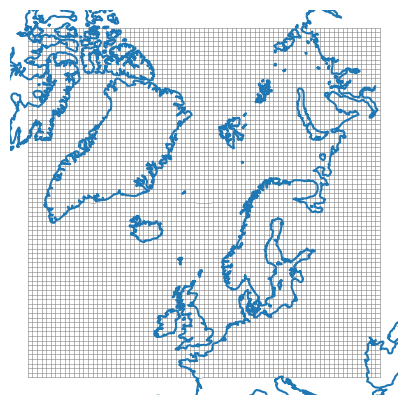

76 x 76 cubed sphere grid
Centered at lon, lat = 0.0, 70.0
Orientation: 1.00 east, 0.00 north, 
Extent: ~46.0 x 46.0 degrees central angle

In [39]:
# Center of the grid (near the North Pole)
lonc, latc = 0, 70         # center latitude ~70°N, center longitude 0°
position = (lonc, latc)     # center position
orientation = 0             # orientation angle in degrees (0 = North up)

# Grid size and resolution
L, W = 7000e3, 7000e3      # 9000 km x 18,000 km to cover auroral region
Lres, Wres = 70e3, 70e3     # grid resolution 70 km

# Ionospheric radius
refh = 120                   # reference height [km]
R = 6371.2 + refh            # Earth radius + ref height [km]
RG = 6500                     # Gamera ionospheric radius [km]

# Construct the cubed sphere grid
grid = lompe.cs.CSgrid(
    lompe.cs.CSprojection(position, orientation),
    L, W, Lres, Wres,
    R=RG * 1e3  # convert km to meters
)

# Plot grid and coastlines
fig, ax0 = plt.subplots(figsize = (5, 5))
ax0.set_axis_off()
for lon, lat in grid.get_grid_boundaries():
    xi, eta = grid.projection.geo2cube(lon, lat)
    ax0.plot(xi, eta, color = 'grey', linewidth = .4)

xlim, ylim = ax0.get_xlim(), ax0.get_ylim()
for cl in grid.projection.get_projected_coastlines():
    ax0.plot(cl[0], cl[1], color = 'C0')
    
ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
plt.show()

grid

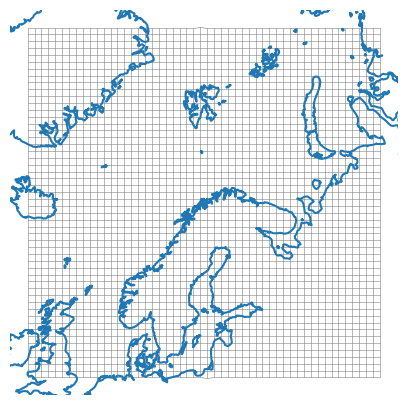

51 x 51 cubed sphere grid
Centered at lon, lat = 20.0, 70.0
Orientation: 1.00 east, 0.00 north, 
Extent: ~30.7 x 30.7 degrees central angle

In [ ]:
#grid for eiscat 3D OSSE
# Here the goal would be to see how well we can give context to Eiscat
# use the usual data and then add a magnetometer where things don't look fully resolve/too smooth on the lompe output. 
# i'll have to make fake magnetometer data (the values don't mater) and add positions I want. 

# i guess first plot lompe output
# then add magnetometer
# then replot output and check if the solution is changed (are there any major differences?). Is it improved? 

# Center over Fennoscandia / EISCAT 3D (~70°N, 20°E)
lonc, latc = 20, 70         # center latitude ~70°N, center longitude 20°
position = (lonc, latc)     # center position
orientation = 0             # orientation angle in degrees (0 = North up)

# Grid size and resolution
L, W = 4000e3, 4000e3  # along orientation (L) ~8000 km, perpendicular (W) ~12,000 km
Lres, Wres = 70e3, 70e3  # 70 km resolution

# Ionospheric radius
refh = 120                   # reference height [km]
R = 6371.2 + refh            # Earth radius + ref height [km]
RG = 6500                     # Gamera ionospheric radius [km]

# Create cubed sphere grid
grid = lompe.cs.CSgrid(
    lompe.cs.CSprojection(position, orientation),
    L, W, Lres, Wres,
    R=RG * 1e3  # convert km to meters
)

# Plot grid and coastlines
fig, ax0 = plt.subplots(figsize = (5, 5))
ax0.set_axis_off()
for lon, lat in grid.get_grid_boundaries():
    xi, eta = grid.projection.geo2cube(lon, lat)
    ax0.plot(xi, eta, color = 'grey', linewidth = .4)

xlim, ylim = ax0.get_xlim(), ax0.get_ylim()
for cl in grid.projection.get_projected_coastlines():
    ax0.plot(cl[0], cl[1], color = 'C0')
    
ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
plt.show()

grid

In [ ]:
#grid for Swarm orbit + iridium

# should I used what I need in SwarmDF?

#### Input data
Next, we load the observational datasets that will be used in this OSSE. 

We start by defining the event (date of observations).

In [ ]:
# Define event date
event = "2012-04-05"
event_date = event[0:4]+event[5:7]+event[8:10] # format YYYYMMDD

# Define event time interval
hour = 1
minute = 19
stime = dt.datetime(int(event[0:4]), int(event[5:7]), int(event[8:10]), hour, minute) # the specific time to model
DT = dt.timedelta(seconds = 2*60) # will select data from stime +- DT 

t0 = stime - DT
t1 = stime + DT
print('Model interval is ' + str(t0) + ' UT to ' + str(t1) + ' UT')

Model interval is 2012-04-05 01:17:00 UT to 2012-04-05 01:21:00 UT


##### Conductance

Then we define the **condutance**. In this experiment, we assume the conductance is perfectly known and derived from the simulated SMILE UVI observations. WHAT DOES IT MEAN?  

Note: the Lompe technique always requires that ionospheric conductances are known.

In [41]:
# Define conductance model using SSUSI image
cmod = Cmodel(grid, event, stime, spline_smoothing = 10, EUV = True, filtersize = 2, how = 'median', 
              param = 'lbhs', tempfile_path = data_dir, basepath = data_dir + '/raw/') #1000

##### Additional datasets 
In addition to the conductance, we also include additional datasets to provide complementary information on ionospheric electrodynamics. In this example, we use **SuperMAG** (horizontal ground magnetic field perturbations), **SuperDARN** (line-of-sight plasma convection measurements) and **Iridium** (horizontal magnetic field measurements) data.

The data files are pre-made and saved in: lompe/examples/sample_dataset/. 
For details on how to prepare your own datasets in this format, see the notebook: *Data_handling_with_Lompe* (Lompe module).

In [42]:
# Dictionary of files: key = variable name, value = (filename, description)
files = {
    "sdarnfn": (f"{event_date}_superdarn_grdmap.h5", "SuperDARN (radar)"),
    "smagfn":  (f"{event_date}_supermag.h5", "SuperMAG (ground magnetometers)"),
    "iridfn":  (f"{event_date}_iridium.h5", "Iridium"),
}

# Build absolute paths and check files
for var, (filename, desc) in files.items():
    path = os.path.join(data_dir, filename)
    # print(path)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {desc} data file at {path}")
    files[var] = (path, desc)  # overwrite filename with full path

# Load data
superdarn = pd.read_hdf(files["sdarnfn"][0])
supermag  = pd.read_hdf(files["smagfn"][0])
iridium   = pd.read_hdf(files["iridfn"][0])

Next, we select the measurements that fall within a short time interval around our event (here, ±2 minutes around 01:19 UT on 5 April 2012).  
The `get_data_subsets` function filters the full-day datasets (SuperDARN, SuperMAG and Iridium) for this time window and prepares Lompe Data objects.  
These objects will later be passed directly to the Lompe **Emodel** object (see end of Step #1 under *Model*).

In [55]:
def get_data_subsets(t0, t1):
    """ return subsets of data loaded above, between t0 and t1 """
    
    # SuperDARN data:
    #sd = superdarn.loc[t0:t1, :]
    sd = superdarn.loc[(superdarn.index >= t0) & (superdarn.index <= t1) & 
                        (superdarn.vlos < 2000)].dropna()
    sd_vlos = sd['vlos'].values
    sd_coords = np.vstack((sd['glon'].values, sd['glat'].values))
    sd_los  = np.vstack((sd['le'].values, sd['ln'].values))

    # SuperMAG data:
    smag = supermag[supermag.lat <= 90] # select northern hemisphere magnetometers? Necessarry?
    smag = smag[t0 : t1].dropna()
    smag_B = np.vstack((smag.Be.values, smag.Bn.values, smag.Bu.values)) # nT
    smag_coords = np.vstack((smag.lon.values, smag.lat.values))

    # add iridium! 
        
    # Make the data objects
    superdarn_data = lompe.Data(sd_vlos        , sd_coords  , LOS = sd_los , datatype = 'convection' , iweight = 1.0, error = 50)
    supermag_data  = lompe.Data(smag_B * 1e-9  , smag_coords,                datatype = 'ground_mag' , iweight = 0.0, error = 10e-9)
    # note the iweight=0.0 given to SuperMAG data to produce zero weight 
    
    return(superdarn_data, supermag_data) # add iridium

# Get the data objects for specified time interval
sd_data, sm_data = get_data_subsets(t0, t1)


#### Model 
Now that we have the condutance and datasets, we can set up the Lompe electric field model.

In [44]:
# Create Emodel object
model = lompe.Emodel(grid, (cmod.hall, cmod.pedersen))

# Add data to model
model.add_data(sd_data, sm_data) #add iridium_data


### Step #2: Run inversion on synthetic data

In Step #1, we set up the Lompe model. The key feature of *LompeOSSE* is that the inversion for the electric field is performed on **synthetic data**.

#### Gamera simulation dataset

We begin by loading the synthetic data:

In [45]:
# Build path to Gamera data file
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..")) # one level above notebook folder  
datapath = os.path.join(repo_root, "data/Gamera_data.h5")

# Check if data file exists
if not os.path.exists(datapath):
    raise FileNotFoundError(
        f"Required file not found: {datapath}\n"
        "Please download it (https://zenodo.org/records/16882035) and place it in the 'data' folder."
    )

# Open Gamera data file
Gdata = h5py.File(datapath, 'r')

Print time steps available in Gamera dataset:

In [46]:
for key in Gdata.keys():
    print(key)

Step#0
Step#12
Step#13
Step#14
Step#16
Step#19
Step#2
Step#20
Step#21
Step#22
Step#3
X
Y


Select one time step:

In [47]:
Gstep = 0 # e.g., if Gstep = 0, the selected time step is Step#0

#### **LompeOSSE** model

Here, we create the LompeOSSE model. The *LompeOSSE* model basically copies the setup from Step #1 — same grid, same dataset types — but replaces the dataset values with simulated measurements from the chosen Gamera run.  

In [48]:
mlt_offset = 0 # explain
hemisphere = 'NORTH' if latc > 0 else 'SOUTH' # remove?

# Define epoch and initialize Apex object for magnetic coordinate calculations 
epoch = 2015. # decimal year
time = yearfrac_to_datetime([epoch])
apx = apexpy.Apex(time[0].year)

# Derive synthetic model
lompeosse_obj = LompeOSSE(model, nstep=Gstep, mlt_off=mlt_offset, epoch=epoch)
osse_model = lompeosse_obj.osse_model

Step#0
Hemisphere: NORTH
/Users/margot/Docs/Academia/Research/Python/lompe_osse/data/Gamera_data.h5
dict_keys(['X', 'Y', 'Average energy', 'Density', 'Field-aligned current', 'Hall conductance', 'IM Energy flux', 'IM Energy flux proton', 'IM average energy', 'IM average energy proton', 'Number flux', 'Pedersen conductance', 'Potential', 'Sound speed', 'Zhang average energy', 'Zhang number flux'])

 Initializing OSSE model...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset is empty
Gamera convection data extracted
space_mag_full dataset is empty
space_mag_fac dataset is empty
fac dataset is empty

 Extracting Gamera conductances

 Clearing Emodel...
Adding Gamera conductances
Adding Gamera datasets


#### Inversion 
Finally, we can run the inversion on the LompeOSSE model:

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


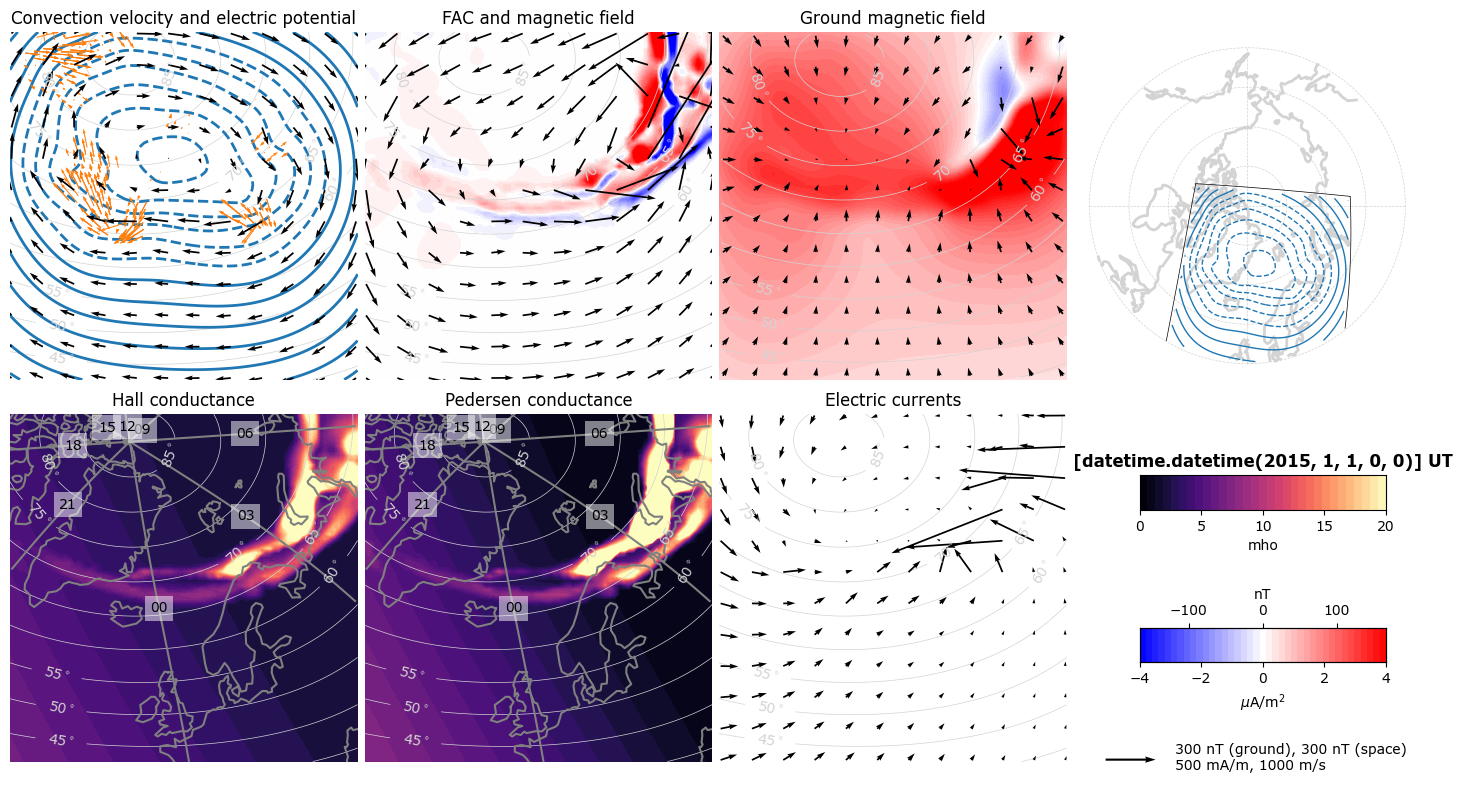

In [49]:
# Run inversion and show output
osse_model.run_inversion(l1 = 1, l2 = 1) # 1) model norm, and 2) gradient of SECS amplitudes (charges) in magnetic eastward direction

# fig = lompe.lompeplot(osse_model, include_data = True, time = time, apex = apx)
fig = lompe.lompeplot(osse_model, include_data = True, time = time, apex = apx, 
                      colorscales = {'fac'        : np.linspace(-2, 2, 40) * 1e-6 * 2,
                                     'ground_mag' : np.linspace(-500, 500, 50) * 1e-9 / 3, # upward component
                                     'hall'       : np.linspace(0, 20, 32), # mho
                                     'pedersen'   : np.linspace(0, 20, 32)}, # mho
                        quiverscales = {'ground_mag'       : 600*1e-9, 
                                        'space_mag_fac'    : 600*1e-9, 
                                        'space_mag_full'   : 600*1e-9, 
                                        'electric_current' : 1}) # 1000*1e-3
plt.show()

The top row shows, from left to right (input data is shown in orange): 
- Convection flow field and electric potential contours
- horizontal magnetic field disturbances 110 km above the ionosphere as black arrows and radial current density as color contours
- horizontal ground magnetic field perturbations as black arrows and radial magnetic field perturbations as color contours
- a map that shows the grid’s position and orientation with respect to apex magnetic latitude and local time.

The bottom row shows, from left to right: 
- Pedersen conductance
- Hall conductance
- horizontal height-integrated ionospheric currents based on Lompe output
- color scale / vector scales

## Step #3: Validate the synthetic Lompe model

Finally, we can validate our synthetic model against Gamera "truth". 


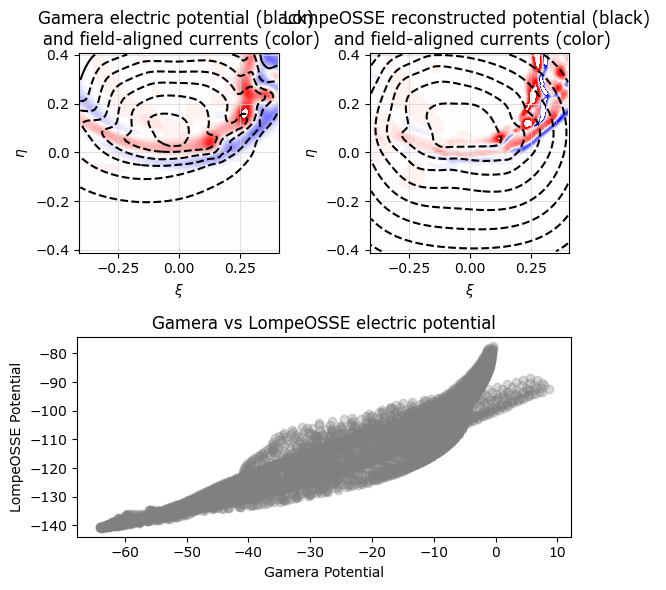

In [50]:
# Extract electric potential and field-aligned currents from Gamera dataset
potG = Gdata[f'Step#{Gstep}']['Potential ' +hemisphere][:]
facG = Gdata[f'Step#{Gstep}']['Field-aligned current ' +hemisphere][:]

# Interpolate Gamera quantities to the user Lompe grid
interp_potG = lompeosse_obj.interp2lompegrid(potG)
interp_facG = lompeosse_obj.interp2lompegrid(facG)

# LompeOSSE-reconstructed quantities
potOSSE = osse_model.E_pot(lon=grid.lon, lat=grid.lat) * 1e-3 # V
potOSSE = potOSSE.reshape(grid.lon.shape)

facOSSE = osse_model.FAC(lon=grid.lon, lat=grid.lat)
facOSSE = facOSSE.reshape(grid.lon.shape)

# Plot

fac_levels = np.linspace(-1.95, 1.95, 40) * 1e-6 * 2

fig = plt.figure(figsize=(6, 6))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# First panel (top-left): Gamera quantities
ax1 = fig.add_subplot(gs[0, 0])  
csax1 = cs.CSplot(ax1, grid, gridtype='cs')
csax1.contour(grid.lon, grid.lat, interp_potG, colors='k')
csax1.contourf(grid.lon, grid.lat, interp_facG*(-1), cmap='bwr', levels=fac_levels*1e6)
ax1.set_title("Gamera electric potential (black) \n and field-aligned currents (color)")

# Second panel (top-right): LompeOSSE-reconstructed quantities
ax2 = fig.add_subplot(gs[0, 1])  
csax2 = cs.CSplot(ax2, grid, gridtype='cs')
csax2.contour(grid.lon, grid.lat, potOSSE, colors='k')
csax2.contourf(grid.lon, grid.lat, facOSSE, cmap='bwr', levels=fac_levels)
ax2.set_title("LompeOSSE reconstructed potential (black) \n and field-aligned currents (color)")

# Third panel (bottom): Scatter plot Gamera VS Lompe-reconstructed potential (should be a line ish)
ax3 = fig.add_subplot(gs[1, :])
ax3.scatter(interp_potG, potOSSE, alpha=.3, color='grey')
ax3.set_xlabel("Gamera Potential")
ax3.set_ylabel("LompeOSSE Potential")
ax3.set_title("Gamera vs LompeOSSE electric potential")
# plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

TODO: Explain what is a good model (straight line)

## optional step

Below you can test how it works when removing some of the input data. Define a new model with different input data, and test it against gamera truth again (repeat steps xx to xx).

You do not need to make an entirely new model if the model object already has been created. The grid/observation geometry, apex, IGRF, etc. will stay the same throughout the entire day. What is changing is the input data. We can replace the input data in the model object using the class function *clear_model()*.

In [51]:
# clear model and pass conductances
osse_model.clear_model(Hall_Pedersen_conductance=(cmod.hall, cmod.pedersen))

################
# Here you can experiment with adding only some of the datasets to the model by changing which lines are comments:

#model.add_data(iridium_data)
osse_model.add_data(sm_data)
#model.add_data(superdarn_data)

################

# Run inversion. l1 and l2 are regularization parameters that control the damping of 
# 1) model norm, and 2) gradient of SECS amplitudes (charges) in magnetic eastward direction
osse_model.run_inversion(l1 = 1, l2 = 1)

# Finally, plot:
fig = lompe.lompeplot(osse_model, include_data = True, time = time, apex = apx, savekw = {'fname':'./output_figures/north_america_mag.pdf'})

The provided iweights were re-scaled so max(iweights)=1
ground_mag: Measurement uncertainty effectively changed from 1e-08 to nan


ValueError: array must not contain infs or NaNs

See how the model output changes when varying the different sources of input data by comparing the first output to that one. 

Here, the point is to demonstrate that... (how well the Lompe technique can reconstruct the Gamera truth)